# Dataset Analysis - CACTUS vs CAMUS

In [1]:
# Configuration
CACTUS_DATA_ROOT = "../CACTUS/Images Dataset"
CAMUS_NIFTI_ROOT = "D:/SRTP_Project__DeepLearning/project/Resources/database_nifti"
SAMPLE_SIZE = 50

In [2]:
import os
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import nibabel as nib

def get_image_files(root_path, extensions=['*.jpg', '*.jpeg', '*.png']):
    root = Path(root_path)
    if not root.exists():
        return []
    files = []
    for ext in extensions:
        files.extend(list(root.rglob(ext)))
    return sorted(files)

def get_category_dirs(root_path):
    root = Path(root_path)
    if not root.exists():
        return []
    dirs = [d for d in root.iterdir() if d.is_dir()]
    return sorted(dirs)

def get_nifti_files(root_path, pattern="*.nii.gz"):
    root = Path(root_path)
    if not root.exists():
        return []
    return sorted(list(root.rglob(pattern)))

# Check CACTUS categories
print("=== CACTUS Categories ===")
cactus_categories = get_category_dirs(CACTUS_DATA_ROOT)
for cat in cactus_categories:
    files = get_image_files(str(cat))
    print(f"  {cat.name}: {len(files)} images")

=== CACTUS Categories ===
  A4C: 7422 images
  PL: 6102 images
  PSAV: 5832 images
  PSMV: 6014 images
  Random: 6021 images
  SC: 6345 images


In [3]:
# Check CAMUS NIfTI structure
print("\n=== CAMUS NIfTI Structure ===")
camus_nifti_files = get_nifti_files(CAMUS_NIFTI_ROOT)
print(f"Total NIfTI files: {len(camus_nifti_files)}")
patient_dirs = sorted(Path(CAMUS_NIFTI_ROOT).glob("patient*"))
print(f"Total patients: {len(patient_dirs)}")

# Check one patient
if patient_dirs:
    sample_patient = patient_dirs[0]
    print(f"\n=== Patient {sample_patient.name} files ===")
    patient_files = list(sample_patient.glob("*.nii.gz"))
    for f in patient_files:
        print(f"  {f.name}")


=== CAMUS NIfTI Structure ===
Total NIfTI files: 6000
Total patients: 500

=== Patient patient0001 files ===
  patient0001_2CH_ED.nii.gz
  patient0001_2CH_ED_gt.nii.gz
  patient0001_2CH_ES.nii.gz
  patient0001_2CH_ES_gt.nii.gz
  patient0001_2CH_half_sequence.nii.gz
  patient0001_2CH_half_sequence_gt.nii.gz
  patient0001_4CH_ED.nii.gz
  patient0001_4CH_ED_gt.nii.gz
  patient0001_4CH_ES.nii.gz
  patient0001_4CH_ES_gt.nii.gz
  patient0001_4CH_half_sequence.nii.gz
  patient0001_4CH_half_sequence_gt.nii.gz


In [4]:
# Analyze NIfTI format
def analyze_nifti_files(nifti_files, sample_size=20):
    sample_files = nifti_files[:sample_size]
    shapes = []
    data_types = []
    file_types = []
    
    for f in sample_files:
        try:
            img = nib.load(str(f))
            shapes.append(img.shape)
            data_types.append(str(img.get_data_dtype()))
            file_types.append(f.name)
        except Exception as e:
            print(f"  Warning: {f.name} - {e}")
    
    return {
        'shapes': shapes,
        'data_types': data_types,
        'file_types': file_types
    }

print("\n=== NIfTI Format Analysis ===")
nifti_info = analyze_nifti_files(camus_nifti_files, 20)
print(f"  Shape examples: {nifti_info['shapes'][:5]}")
print(f"  Data types: {set(nifti_info['data_types'])}")
file_types_unique = list(set([Path(f).name.split('_')[1] if '_' in f else f for f in nifti_info['file_types']]))
print(f"  File types: {file_types_unique[:10]}")


=== NIfTI Format Analysis ===
  Shape examples: [(549, 389), (549, 389), (549, 389), (549, 389), (549, 389, 18)]
  Data types: {'float32'}
  File types: ['2CH', '4CH']


## CACTUS Image Format

In [5]:
def analyze_image_format(image_dir, sample_size=50):
    files = get_image_files(image_dir)[:sample_size]
    
    if not files:
        return None
    
    formats = set()
    modes = set()
    sizes = []
    
    for f in files:
        try:
            img = Image.open(f)
            formats.add(img.format or 'UNKNOWN')
            modes.add(img.mode)
            sizes.append(img.size)
        except Exception as e:
            print(f"  Warning: {f.name}: {e}")
    
    return {
        'files': files,
        'formats': formats,
        'modes': modes,
        'sizes': sizes
    }

print("=== CACTUS Image Format ===")
cactus_sample_cat = cactus_categories[0] if cactus_categories else None
if cactus_sample_cat:
    cactus_info = analyze_image_format(str(cactus_sample_cat), SAMPLE_SIZE)
    if cactus_info:
        print(f"  Format: {cactus_info['formats']}")
        print(f"  Mode: {cactus_info['modes']}")
        print(f"  Size: {cactus_info['sizes'][0]}")
        cactus_files = cactus_info['files']

=== CACTUS Image Format ===
  Format: {'JPEG'}
  Mode: {'RGB'}
  Size: (1920, 1080)


## Pixel Distribution

In [6]:
# CACTUS pixel distribution
def analyze_cactus_pixel_distribution(image_files, label="CACTUS", sample_size=20):
    all_stats = []
    
    for f in image_files[:sample_size]:
        try:
            img = Image.open(f)
            arr = np.array(img, dtype=np.float32)
            all_stats.append({
                'mean': arr.mean(),
                'std': arr.std(),
                'min': arr.min(),
                'max': arr.max()
            })
        except:
            pass
    
    if not all_stats:
        return None
    
    result = {
        'mean': np.mean([s['mean'] for s in all_stats]),
        'std': np.mean([s['std'] for s in all_stats]),
        'min': np.mean([s['min'] for s in all_stats]),
        'max': np.mean([s['max'] for s in all_stats]),
    }
    
    print(f"=== {label} Pixel Distribution ===")
    print(f"  Mean: {result['mean']:.2f}")
    print(f"  Std: {result['std']:.2f}")
    print(f"  Range: {result['min']:.2f} - {result['max']:.2f}")
    
    return result

cactus_stats = analyze_cactus_pixel_distribution(cactus_files, "CACTUS")

=== CACTUS Pixel Distribution ===
  Mean: 30.22
  Std: 56.25
  Range: 0.00 - 255.00


In [7]:
# CAMUS NIfTI pixel distribution
def analyze_camus_nifti_distribution(nifti_files, label="CAMUS", sample_size=20):
    ch2_files = [f for f in nifti_files if '2CH' in f.name]
    ch2_files = ch2_files[:sample_size]
    
    all_stats = []
    
    for f in ch2_files:
        try:
            img = nib.load(str(f))
            data = img.get_fdata()
            
            if len(data.shape) == 4:
                data = data.reshape(-1)
            elif len(data.shape) == 3:
                data = data.reshape(-1)
            
            all_stats.append({
                'mean': float(data.mean()),
                'std': float(data.std()),
                'min': float(data.min()),
                'max': float(data.max())
            })
        except Exception as e:
            print(f"  Warning: {f.name} - {e}")
    
    if not all_stats:
        return None
    
    result = {
        'mean': np.mean([s['mean'] for s in all_stats]),
        'std': np.mean([s['std'] for s in all_stats]),
        'min': np.mean([s['min'] for s in all_stats]),
        'max': np.mean([s['max'] for s in all_stats]),
    }
    
    print(f"=== {label} NIfTI Pixel Distribution (2CH) ===")
    print(f"  Mean: {result['mean']:.2f}")
    print(f"  Std: {result['std']:.2f}")
    print(f"  Range: {result['min']:.2f} - {result['max']:.2f}")
    
    return result

camus_stats = analyze_camus_nifti_distribution(camus_nifti_files, "CAMUS")

=== CAMUS NIfTI Pixel Distribution (2CH) ===
  Mean: 34.09
  Std: 37.08
  Range: 0.00 - 128.60


## Visualization

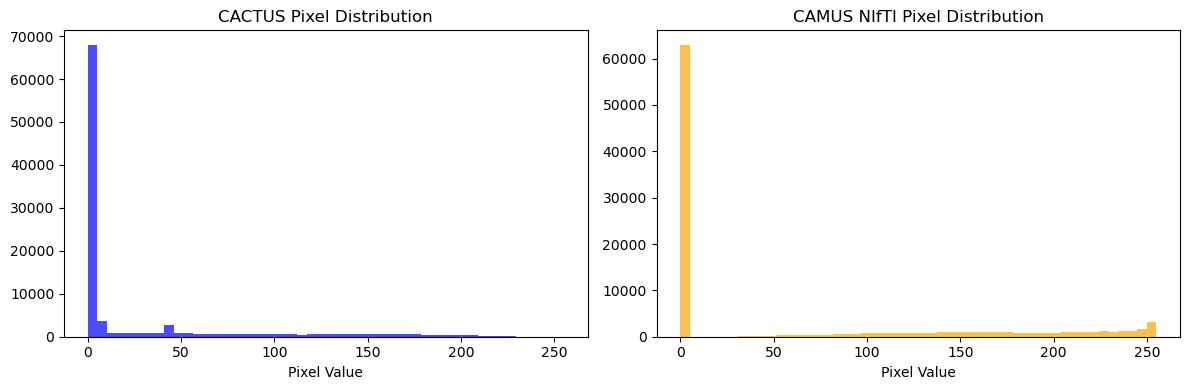

Saved: ../debug/pixel_distribution.png


In [8]:
# Pixel distribution histogram
import os
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CACTUS
if cactus_files:
    cactus_pixels = []
    for f in cactus_files[:10]:
        img = Image.open(f)
        arr = np.array(img).flatten()
        cactus_pixels.extend(arr)
    if len(cactus_pixels) > 100000:
        cactus_pixels = np.random.choice(cactus_pixels, 100000, replace=False)
    axes[0].hist(cactus_pixels, bins=50, alpha=0.7, color='blue')
    axes[0].set_title("CACTUS Pixel Distribution")
    axes[0].set_xlabel("Pixel Value")

# CAMUS
ch2_files = [f for f in camus_nifti_files[:10] if '2CH' in f.name]
camus_pixels = np.array([])
for f in ch2_files[:3]:
    img = nib.load(str(f))
    data = img.get_fdata()
    if len(data.shape) == 4:
        data = data.reshape(-1)
    elif len(data.shape) == 3:
        data = data.reshape(-1)
    camus_pixels = np.concatenate([camus_pixels, data.flatten()])
if len(camus_pixels) > 100000:
    camus_pixels = np.random.choice(camus_pixels, 100000, replace=False)
axes[1].hist(camus_pixels, bins=50, alpha=0.7, color='orange')
axes[1].set_title("CAMUS NIfTI Pixel Distribution")
axes[1].set_xlabel("Pixel Value")

plt.tight_layout()
output_dir = Path("../debug")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(str(output_dir / "pixel_distribution.png"), dpi=150)
plt.show()
print("Saved: ../debug/pixel_distribution.png")

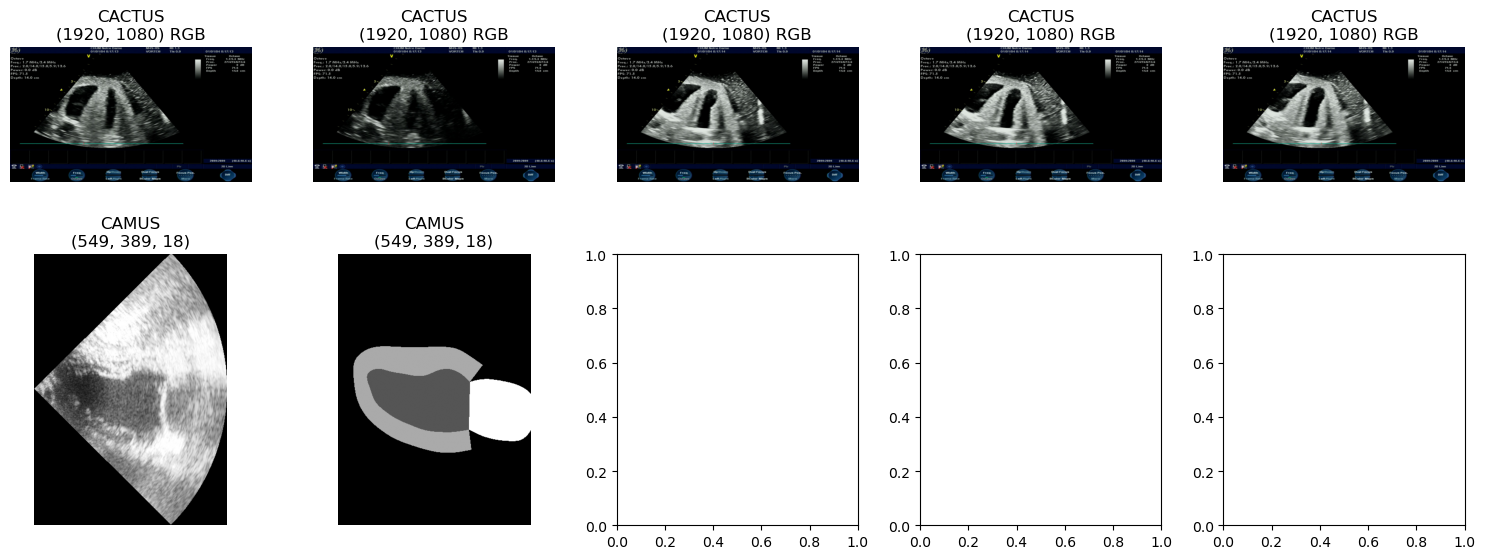

Saved: ../debug/sample_images.png


In [9]:
# Sample images visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# CACTUS
for i, f in enumerate(cactus_files[:5]):
    img = Image.open(f)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"CACTUS\n{img.size} {img.mode}")
    axes[0, i].axis('off')

# CAMUS
ch2_files = [f for f in camus_nifti_files[:10] if '2CH' in f.name and 'half_sequence' in f.name]
for i, f in enumerate(ch2_files[:5]):
    img = nib.load(str(f))
    data = img.get_fdata()
    if len(data.shape) == 4:
        frame = data[:, :, 0, data.shape[3]//2]
    elif len(data.shape) == 3:
        frame = data[:, :, data.shape[2]//2]
    else:
        frame = data
    axes[1, i].imshow(frame, cmap='gray')
    axes[1, i].set_title(f"CAMUS\n{data.shape}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(str(output_dir / "sample_images.png"), dpi=150)
plt.show()
print("Saved: ../debug/sample_images.png")

## Summary

In [10]:
print("=" * 50)
print("Analysis Summary")
print("=" * 50)

print("\n[1. Data Format]")
print(f"  CACTUS: JPEG image, {cactus_info['modes']}")
print(f"  CAMUS:  NIfTI format (4D ultrasound sequence)")

print("\n[2. Image Size]")
print(f"  CACTUS: {cactus_info['sizes'][0]}")
print(f"  CAMUS:  {nifti_info['shapes'][0]}")

print("\n[3. Pixel Distribution]")
print(f"  CACTUS: mean={cactus_stats['mean']:.1f}, std={cactus_stats['std']:.1f}")
print(f"  CAMUS:  mean={camus_stats['mean']:.1f}, std={camus_stats['std']:.1f}")

print("\n[4. Key Differences]")
print("  WARNING: CACTUS is static JPEG, CAMUS is ultrasound video frames")
print("  WARNING: Pixel range differs: CACTUS 0-255, CAMUS raw ultrasound values")
print("  WARNING: CAMUS needs frame extraction and normalization")

print("\n[5. Suggested Preprocessing]")
print("  1. Frame extraction: extract key frames from NIfTI")
print("  2. Normalization: normalize CAMUS to 0-255")
print("  3. Grayscale: convert to grayscale")
print("  4. Resize: unify to 224x224")

print("\nDone!")

Analysis Summary

[1. Data Format]
  CACTUS: JPEG image, {'RGB'}
  CAMUS:  NIfTI format (4D ultrasound sequence)

[2. Image Size]
  CACTUS: (1920, 1080)
  CAMUS:  (549, 389)

[3. Pixel Distribution]
  CACTUS: mean=30.2, std=56.2
  CAMUS:  mean=34.1, std=37.1

[4. Key Differences]

[5. Suggested Preprocessing]
  1. Frame extraction: extract key frames from NIfTI
  2. Normalization: normalize CAMUS to 0-255
  3. Grayscale: convert to grayscale
  4. Resize: unify to 224x224

Done!
